# Öğrenci Başarısı — Lojistik Regresyon

**Veri:** Students Performance Dataset.csv (5.000 öğrenci, 23 değişken)
**Hedef:** Öğrencinin dönem sonunda başarılı olup olmayacağı, dönem içi verilerle tahmin ediliyor.
Bu projede öğrencilerin dönem sonu başarı durumu, lojistik regresyon ile **başarılı (1)** / **başarısız (0)** olarak sınıflandırılmaktadır. Ayrıca veri sızıntısının model performansına etkisini görmek için farklı özellik setleri karşılaştırılmaktadır.


## 2. Gerekli Kütüphaneler

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

plt.rcParams['figure.dpi'] = 150

import warnings
warnings.filterwarnings('ignore')

## 3. Veriyi Yükleme ve Keşfetme

In [43]:
df = pd.read_csv("Students Performance Dataset.csv")

print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
print(f"\nSütun isimleri:\n{', '.join(df.columns.tolist())}")
print(f"\nİlk 5 satır:")
display(df.head())
print(f"\nVeri seti istatistikleri:")
display(df.describe())
print(f"\nEksik veri kontrolü:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())

Veri seti boyutu: 5000 satır, 23 sütun

Sütun isimleri:
Student_ID, First_Name, Last_Name, Email, Gender, Age, Department, Attendance (%), Midterm_Score, Final_Score, Assignments_Avg, Quizzes_Avg, Participation_Score, Projects_Score, Total_Score, Grade, Study_Hours_per_Week, Extracurricular_Activities, Internet_Access_at_Home, Parent_Education_Level, Family_Income_Level, Stress_Level (1-10), Sleep_Hours_per_Night

İlk 5 satır:


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5



Veri seti istatistikleri:


,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,21.048400,75.356076,70.701924,69.546552,74.956320,74.836214,49.963720,74.78305,71.652097,17.521140,5.507200,6.514420
std,1.989786,14.392716,17.436325,17.108996,14.404287,14.423848,28.989785,14.54243,7.230097,7.193035,2.886662,1.446155
min,18.000000,50.010000,40.000000,40.010000,50.000000,50.000000,0.000000,50.00000,50.602000,5.000000,1.000000,4.000000
25%,19.000000,62.945000,55.707500,54.697500,62.340000,62.357500,25.075000,61.97000,66.533875,11.500000,3.000000,5.300000
50%,21.000000,75.670000,70.860000,69.485000,75.090000,74.905000,49.600000,74.54000,71.696250,17.400000,6.000000,6.500000
75%,23.000000,87.862500,85.760000,83.922500,87.352500,87.292500,75.500000,87.63000,76.711625,23.700000,8.000000,7.800000
max,24.000000,100.000000,99.990000,99.980000,99.990000,99.990000,100.000000,100.00000,95.091500,30.000000,10.000000,9.000000



Eksik veri kontrolü:
Parent_Education_Level    1025


### 3.1 Veri Seti Hakkında Kritik Bir Bulgu

Arşivde iki dosya var: `Students Performance Dataset.csv` ve `Students_Grading_Dataset_Biased.csv`.

**Biased dosya kullanılmamalıdır.** O dosyada `Total_Score` ile hiçbir değişken arasında korelasyon yoktur (tüm |r| < 0.04), yani hedef değişken tamamen rastgeledir. Bu dosyada kurulan hiçbir model öğrenemez.

İkinci ve daha önemli bulgu: `Total_Score` **deterministik bir formüldür.** Aşağıdaki hücrede bunu doğruluyoruz.

In [44]:
# Total_Score gerçekten bir formül mü? Bileşen notlarıyla lineer regresyon kuralım.
from sklearn.linear_model import LinearRegression

bilesenler = ['Midterm_Score', 'Final_Score', 'Assignments_Avg',
              'Quizzes_Avg', 'Participation_Score', 'Projects_Score']

kontrol = LinearRegression().fit(df[bilesenler], df['Total_Score'])
print(f"R² = {kontrol.score(df[bilesenler], df['Total_Score']):.6f}")
print("\nBulunan ağırlıklar:")
for ad, w in zip(bilesenler, kontrol.coef_):
    print(f"  {ad:<22}: {w:.2f}")
print(f"  {'sabit terim':<22}: {kontrol.intercept_:.2f}")

print("\n>>> R² = 1.000000 → Total_Score bu altı notun ağırlıklı ortalamasıdır.")
print(">>> Bu altı notu birlikte özellik olarak kullanmak DAİRESEL olur:")
print(">>> model tahmin etmez, sadece formülü geri çözer.")

R² = 1.000000

Bulunan ağırlıklar:
  Midterm_Score         : 0.15
  Final_Score           : 0.25
  Assignments_Avg       : 0.15
  Quizzes_Avg           : 0.10
  Participation_Score   : 0.05
  Projects_Score        : 0.30
  sabit terim           : 0.00

>>> R² = 1.000000 → Total_Score bu altı notun ağırlıklı ortalamasıdır.
>>> Bu altı notu birlikte özellik olarak kullanmak DAİRESEL olur:
>>> model tahmin etmez, sadece formülü geri çözer.


### 3.2 Hedef Değişkenin Tanımlanması

Veri setinde hazır ikili bir hedef yok. `Grade` sütunu A–F harf notu, `Total_Score` ise sürekli puan.

Lojistik regresyon için ikili hedefi kendimiz türetiyoruz:

$$\text{Basari} = \begin{cases} 1 & \text{Total\_Score} \geq 70 \quad (\text{C ve üzeri}) \\ 0 & \text{Total\_Score} < 70 \quad (\text{D veya F}) \end{cases}$$

In [45]:
# Harf notu - puan aralığı ilişkisini kontrol edelim
print("Harf notlarının puan aralıkları:")
display(df.groupby('Grade')['Total_Score'].agg(['min', 'max', 'count']).round(2))

# İkili hedef değişkeni oluştur
df['Basari'] = (df['Total_Score'] >= 70).astype(int)

print("\nSınıf dağılımı (Basari):")
print(df['Basari'].value_counts().to_string())
print(f"\nOranlar: Başarılı %{df['Basari'].mean()*100:.1f} | Başarısız %{(1-df['Basari'].mean())*100:.1f}")
print("\n>>> Sınıflar makul dengede, ayrıca dengeleme (SMOTE vb.) gerekmiyor.")

Harf notlarının puan aralıkları:


,min,max,count
Grade,,,
A,90.09,95.09,16
B,80.00,89.97,638
C,70.00,80.00,2307
D,60.01,70.00,1760
F,50.60,59.99,279



Sınıf dağılımı (Basari):
Basari
1    2961
0    2039

Oranlar: Başarılı %59.2 | Başarısız %40.8

>>> Sınıflar makul dengede, ayrıca dengeleme (SMOTE vb.) gerekmiyor.


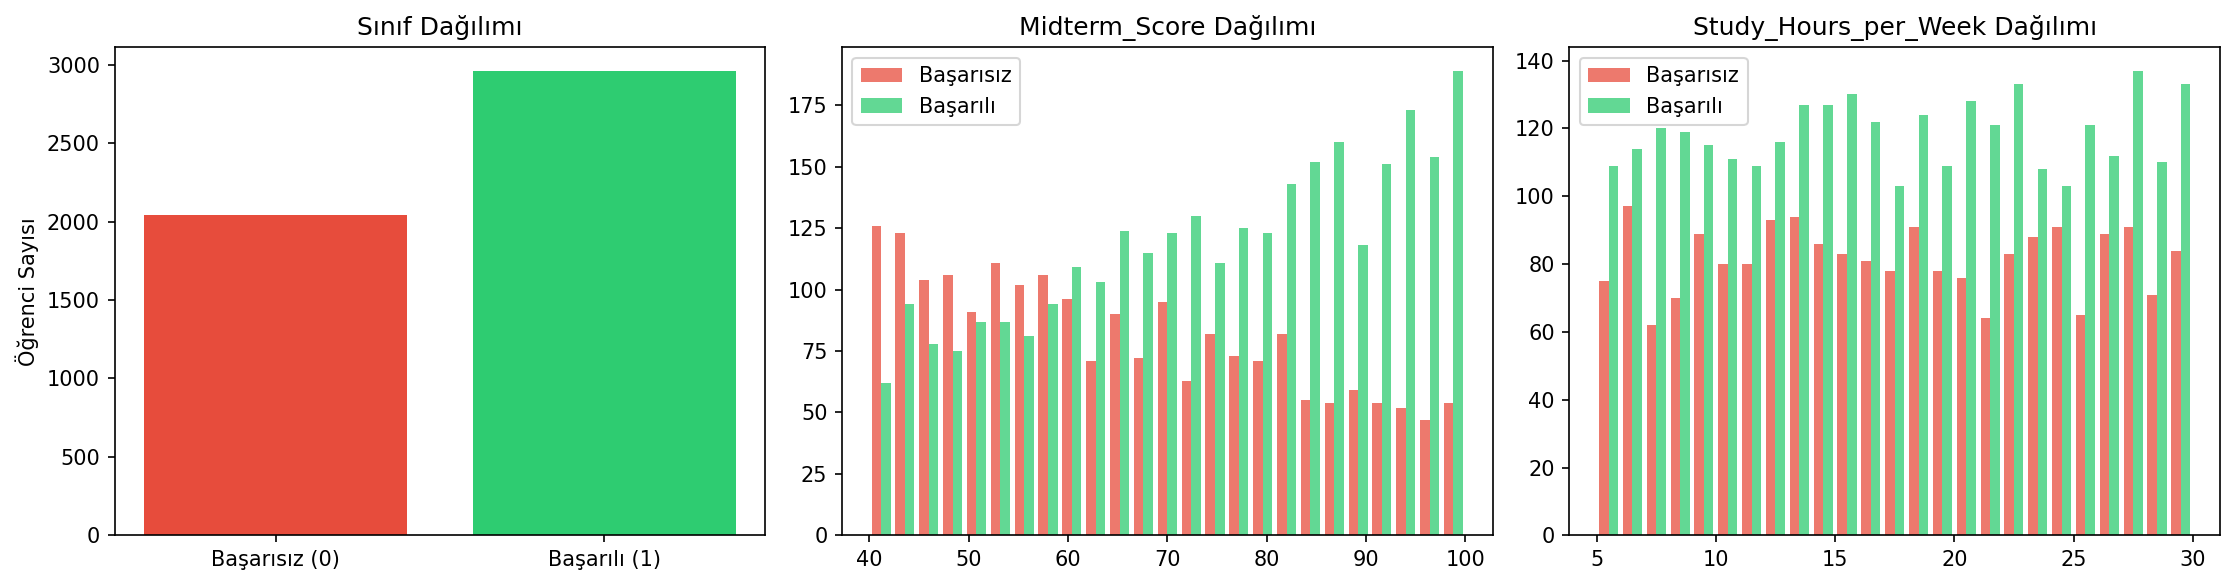

Midterm_Score iki sınıfta belirgin biçimde ayrışıyor.
Study_Hours_per_Week ise neredeyse tamamen üst üste — ayırt edici değil.


In [46]:
# Sınıf dağılımı ve bazı değişkenlerin sınıflara göre dağılımı
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].bar(['Başarısız (0)', 'Başarılı (1)'],
          df['Basari'].value_counts().sort_index().values,
          color=['#e74c3c', '#2ecc71'])
ax[0].set_title('Sınıf Dağılımı')
ax[0].set_ylabel('Öğrenci Sayısı')

for i, kolon in enumerate(['Midterm_Score', 'Study_Hours_per_Week']):
    ax[i+1].hist([df[df.Basari == 0][kolon], df[df.Basari == 1][kolon]],
                 bins=25, label=['Başarısız', 'Başarılı'],
                 color=['#e74c3c', '#2ecc71'], alpha=0.75)
    ax[i+1].set_title(f'{kolon} Dağılımı')
    ax[i+1].legend()

plt.tight_layout()
plt.show()

print("Midterm_Score iki sınıfta belirgin biçimde ayrışıyor.")
print("Study_Hours_per_Week ise neredeyse tamamen üst üste — ayırt edici değil.")

## 4. Özellik Seçimi — Sızıntıdan Kaçınmak

Bölüm 3.1'de `Total_Score`'un altı notun ağırlıklı ortalaması olduğunu gösterdik. Buradan üç farklı özellik seti tanımlıyoruz ve hangisinin **gerçek** bir tahmin problemi olduğunu tartışıyoruz:

| Set | İçerik | Durum |
|---|---|---|
| **A** | Altı bileşen notunun tamamı | ❌ Dairesel — hedef bunlardan hesaplanıyor |
| **B** | Dönem içi notlar + davranışsal + demografik | ✅ Gerçek erken tahmin problemi |
| **C** | Sadece davranışsal/demografik | ⚠️ Referans (baseline) |

**Set B'nin mantığı:** Dönem ortasındayız. `Final_Score` ve `Projects_Score` henüz belli değil (bunlar toplam notun %55'i). Elimizde vize, ödev, quiz, katılım notları ve devam/çalışma alışkanlıkları var. Soru şu: **bu bilgiyle öğrencinin dönem sonunda geçip geçmeyeceğini öngörebilir miyiz?**

Ana modelimiz Set B üzerine kurulacak; A ve C karşılaştırma için Bölüm 9'da eğitilecek.

In [47]:
# Sayısal özellikler (dönem içi + davranışsal + demografik)
sayisal_ozellikler = [
    'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
    'Attendance (%)', 'Study_Hours_per_Week', 'Sleep_Hours_per_Night',
    'Stress_Level (1-10)', 'Age'
]

# Kategorik özellikler (one-hot encoding uygulanacak)
kategorik_ozellikler = [
    'Gender', 'Department', 'Extracurricular_Activities',
    'Internet_Access_at_Home', 'Family_Income_Level'
]

print("Kategorik değişkenlerin seviyeleri:")
for k in kategorik_ozellikler:
    print(f"  {k:<30}: {df[k].unique().tolist()}")

# NOT: Parent_Education_Level %20 oranında eksik olduğu için dışarıda bırakıldı.
print(f"\nParent_Education_Level eksik oranı: %{df['Parent_Education_Level'].isnull().mean()*100:.1f} → kullanılmadı")

Kategorik değişkenlerin seviyeleri:
  Gender                        : ['Female', 'Male']
  Department                    : ['Mathematics', 'Business', 'Engineering', 'CS']
  Extracurricular_Activities    : ['Yes', 'No']
  Internet_Access_at_Home       : ['No', 'Yes']
  Family_Income_Level           : ['Medium', 'Low', 'High']

Parent_Education_Level eksik oranı: %20.5 → kullanılmadı


In [48]:
# One-hot encoding ve özellik matrisinin oluşturulması
X_kategorik = pd.get_dummies(df[kategorik_ozellikler], drop_first=True).astype(int)
X = pd.concat([df[sayisal_ozellikler], X_kategorik], axis=1)
y = df['Basari']

print(f"Özellik matrisi (X): {X.shape}")
print(f"Hedef vektör (y):   {y.shape}")
print(f"\nToplam {X.shape[1]} özellik:")
print(f"  {len(sayisal_ozellikler)} sayısal + {X_kategorik.shape[1]} kukla (dummy) değişken")
print(f"\nÖzellikler: {X.columns.tolist()}")
display(X.head())

Özellik matrisi (X): (5000, 17)
Hedef vektör (y):   (5000,)

Toplam 17 özellik:
  9 sayısal + 8 kukla (dummy) değişken

Özellikler: ['Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Attendance (%)', 'Study_Hours_per_Week', 'Sleep_Hours_per_Night', 'Stress_Level (1-10)', 'Age', 'Gender_Male', 'Department_CS', 'Department_Engineering', 'Department_Mathematics', 'Extracurricular_Activities_Yes', 'Internet_Access_at_Home_Yes', 'Family_Income_Level_Low', 'Family_Income_Level_Medium']


,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Attendance (%),Study_Hours_per_Week,Sleep_Hours_per_Night,Stress_Level (1-10),Age,Gender_Male,Department_CS,Department_Engineering,Department_Mathematics,Extracurricular_Activities_Yes,Internet_Access_at_Home_Yes,Family_Income_Level_Low,Family_Income_Level_Medium
0,40.61,73.69,53.17,73.4,97.36,10.3,5.9,1,22,0,0,0,1,1,0,0,1
1,57.27,74.23,98.23,88.0,97.71,27.1,4.3,4,18,1,0,0,0,0,0,1,0
2,41.84,85.85,50.00,4.7,99.52,12.4,6.1,9,24,1,0,1,0,1,0,1,0
3,45.65,68.10,66.27,4.2,90.38,25.5,4.9,8,24,0,0,1,0,0,1,1,0
4,53.13,67.66,83.98,64.3,59.41,13.3,4.5,6,23,0,1,0,0,1,0,0,1


## 5. Eğitim/Test Ayrımı

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti:   {X_test.shape[0]} örnek")
print(f"\nEğitim seti sınıf dağılımı:\n{y_train.value_counts().to_string()}")
print(f"\nTest seti sınıf dağılımı:\n{y_test.value_counts().to_string()}")
print("\n>>> stratify=y sayesinde sınıf oranları iki sette de korundu.")

Eğitim seti: 4000 örnek
Test seti:   1000 örnek

Eğitim seti sınıf dağılımı:
Basari
1    2369
0    1631

Test seti sınıf dağılımı:
Basari
1    592
0    408

>>> stratify=y sayesinde sınıf oranları iki sette de korundu.


## 6. Özellik Ölçeklendirme

`fit_transform` sadece eğitim setine, `transform` test setine uygulanıyor.

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Özellikler standardize edildi (mean=0, std=1)")
print(f"\nEğitim seti ilk satır (ölçeklenmiş):")
print(np.round(X_train_scaled[0], 3))
print(f"\nÖlçeklenmiş eğitim seti ortalamaları (≈0): {np.round(X_train_scaled.mean(axis=0)[:5], 4)}")
print(f"Ölçeklenmiş eğitim seti std'leri (≈1):    {np.round(X_train_scaled.std(axis=0)[:5], 4)}")

Özellikler standardize edildi (mean=0, std=1)

Eğitim seti ilk satır (ölçeklenmiş):
[ 0.963  0.575  1.472  1.219  0.058 -1.202  1.289 -0.168  0.975 -1.02
 -0.579 -0.583  1.751  0.994  0.987  1.396 -0.71 ]

Ölçeklenmiş eğitim seti ortalamaları (≈0): [ 0. -0.  0. -0. -0.]
Ölçeklenmiş eğitim seti std'leri (≈1):    [1. 1. 1. 1. 1.]


## 7. Model Eğitimi

`LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000)`

In [51]:
model = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42
)
model.fit(X_train_scaled, y_train)
print("Model eğitimi tamamlandı.")

Model eğitimi tamamlandı.


In [52]:
# Model katsayıları
print(f"Kesişim (bias - β₀): {model.intercept_[0]:.4f}")
print(f"\nKatsayılar (β₁ ... βₙ) ve odds oranları:")
coef_df = pd.DataFrame({
    'Özellik': X.columns,
    'Katsayı': model.coef_[0],
    'Odds Oranı': np.exp(model.coef_[0]),
    '|Katsayı|': np.abs(model.coef_[0])
}).sort_values('|Katsayı|', ascending=False)
display(coef_df)

Kesişim (bias - β₀): 0.4600

Katsayılar (β₁ ... βₙ) ve odds oranları:


,Özellik,Katsayı,Odds Oranı,|Katsayı|
1,Assignments_Avg,0.695238,2.004185,0.695238
0,Midterm_Score,0.652759,1.920834,0.652759
2,Quizzes_Avg,0.383520,1.467440,0.383520
3,Participation_Score,0.360425,1.433938,0.360425
5,Study_Hours_per_Week,0.059874,1.061703,0.059874
15,Family_Income_Level_Low,-0.047901,0.953228,0.047901
14,Internet_Access_at_Home_Yes,0.043726,1.044696,0.043726
12,Department_Mathematics,-0.035169,0.965443,0.035169
13,Extracurricular_Activities_Yes,-0.031388,0.969099,0.031388
4,Attendance (%),-0.028377,0.972022,0.028377


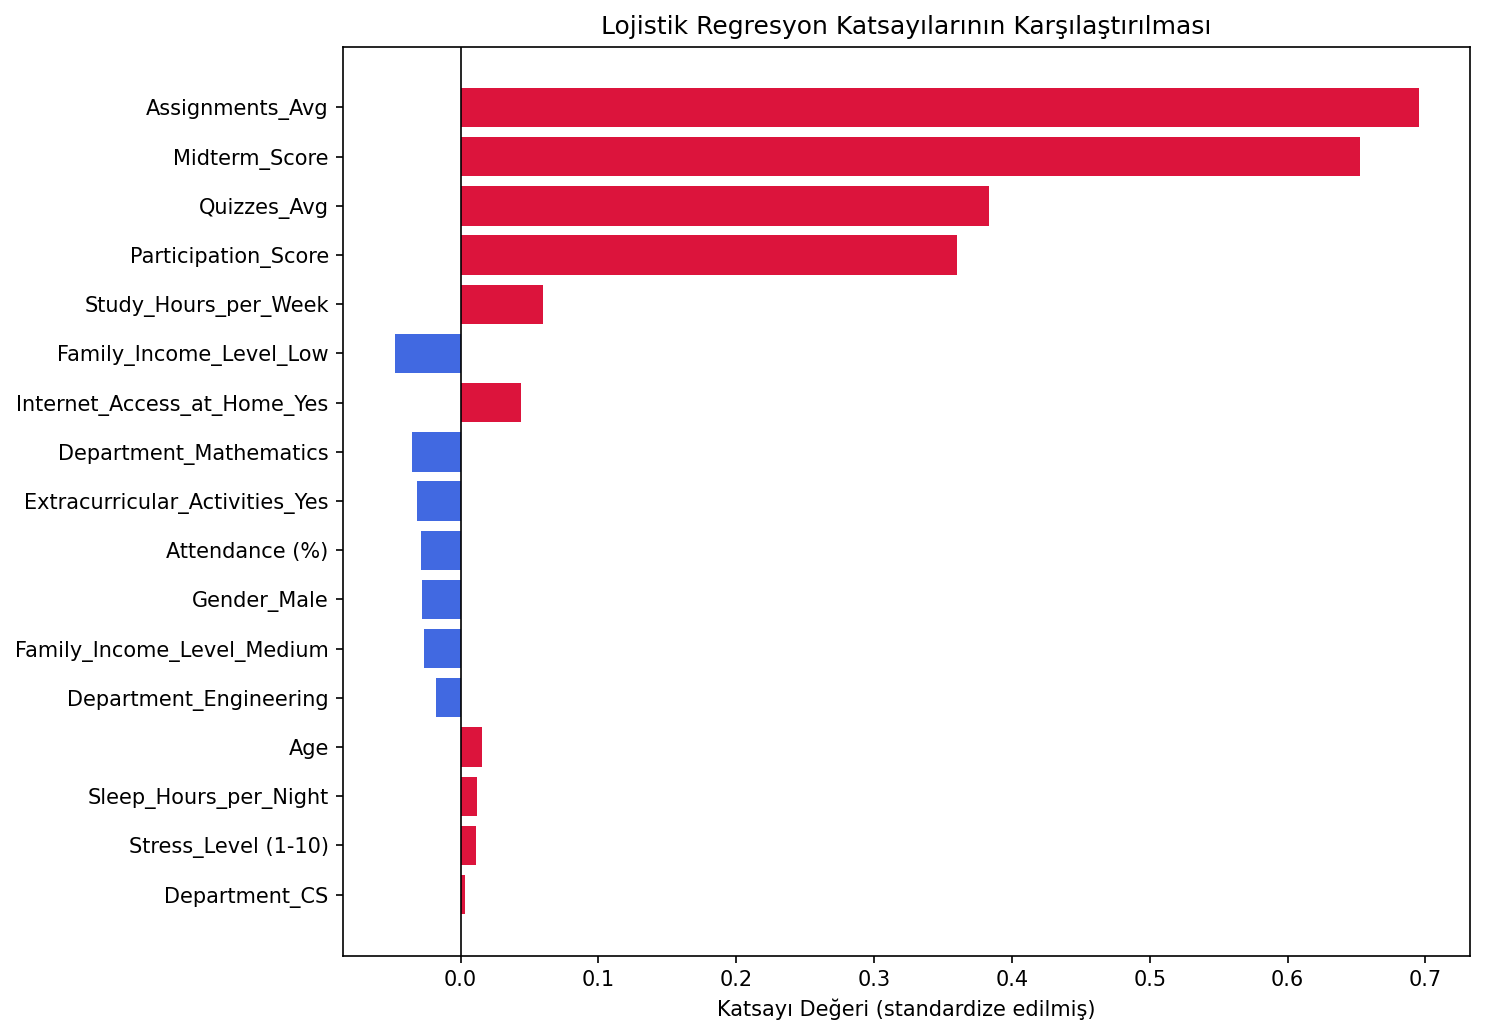

Kırmızı = başarı olasılığını artırıyor | Mavi = azaltıyor


In [53]:
# Lojistik Regresyon Katsayılarının Karşılaştırılması
plt.figure(figsize=(10, 7))
colors = ['crimson' if c > 0 else 'royalblue' for c in coef_df['Katsayı']]
plt.barh(coef_df['Özellik'], coef_df['Katsayı'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Katsayı Değeri (standardize edilmiş)')
plt.title('Lojistik Regresyon Katsayılarının Karşılaştırılması')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Kırmızı = başarı olasılığını artırıyor | Mavi = azaltıyor")

## 8. Model Değerlendirme

In [54]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print("=== MODEL PERFORMANS METRİKLERİ ===")
print(f"  Doğruluk (Accuracy):     {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"  Hassasiyet (Precision):  {precision:.4f}  ({(precision*100):.2f}%)")
print(f"  Duyarlılık (Recall):     {recall:.4f}  ({(recall*100):.2f}%)")
print(f"  F1-Skoru:                {f1:.4f}")
print(f"  AUC-ROC:                 {auc_roc:.4f}")

# Referans nokta: her şeye "başarılı" diyen aptal model
baseline = y_test.mean()
print(f"\n  Referans (hep '1' diyen model): {baseline:.4f}")
print(f"  Modelin referansa göre kazancı: +{(accuracy - baseline)*100:.2f} puan")

=== MODEL PERFORMANS METRİKLERİ ===
  Doğruluk (Accuracy):     0.6810  (68.10%)
  Hassasiyet (Precision):  0.7040  (70.40%)
  Duyarlılık (Recall):     0.7956  (79.56%)
  F1-Skoru:                0.7470
  AUC-ROC:                 0.7378

  Referans (hep '1' diyen model): 0.5920
  Modelin referansa göre kazancı: +8.90 puan


In [55]:
# Karmaşıklık Matrisi
cm = confusion_matrix(y_test, y_pred)

print("=== KARIŞIKLIK MATRİSİ (Confusion Matrix) ===")
print(f"               Tahmin: 0    Tahmin: 1")
print(f"  Gerçek: 0     {cm[0,0]:3d} (TN)       {cm[0,1]:3d} (FP)")
print(f"  Gerçek: 1     {cm[1,0]:3d} (FN)       {cm[1,1]:3d} (TP)")
print()
print("=== SINIFLANDIRMA RAPORU ===")
print(classification_report(y_test, y_pred, target_names=["Başarısız", "Başarılı"]))

=== KARIŞIKLIK MATRİSİ (Confusion Matrix) ===
               Tahmin: 0    Tahmin: 1
  Gerçek: 0     210 (TN)       198 (FP)
  Gerçek: 1     121 (FN)       471 (TP)

=== SINIFLANDIRMA RAPORU ===
              precision    recall  f1-score   support

   Başarısız       0.63      0.51      0.57       408
    Başarılı       0.70      0.80      0.75       592

    accuracy                           0.68      1000
   macro avg       0.67      0.66      0.66      1000
weighted avg       0.68      0.68      0.67      1000



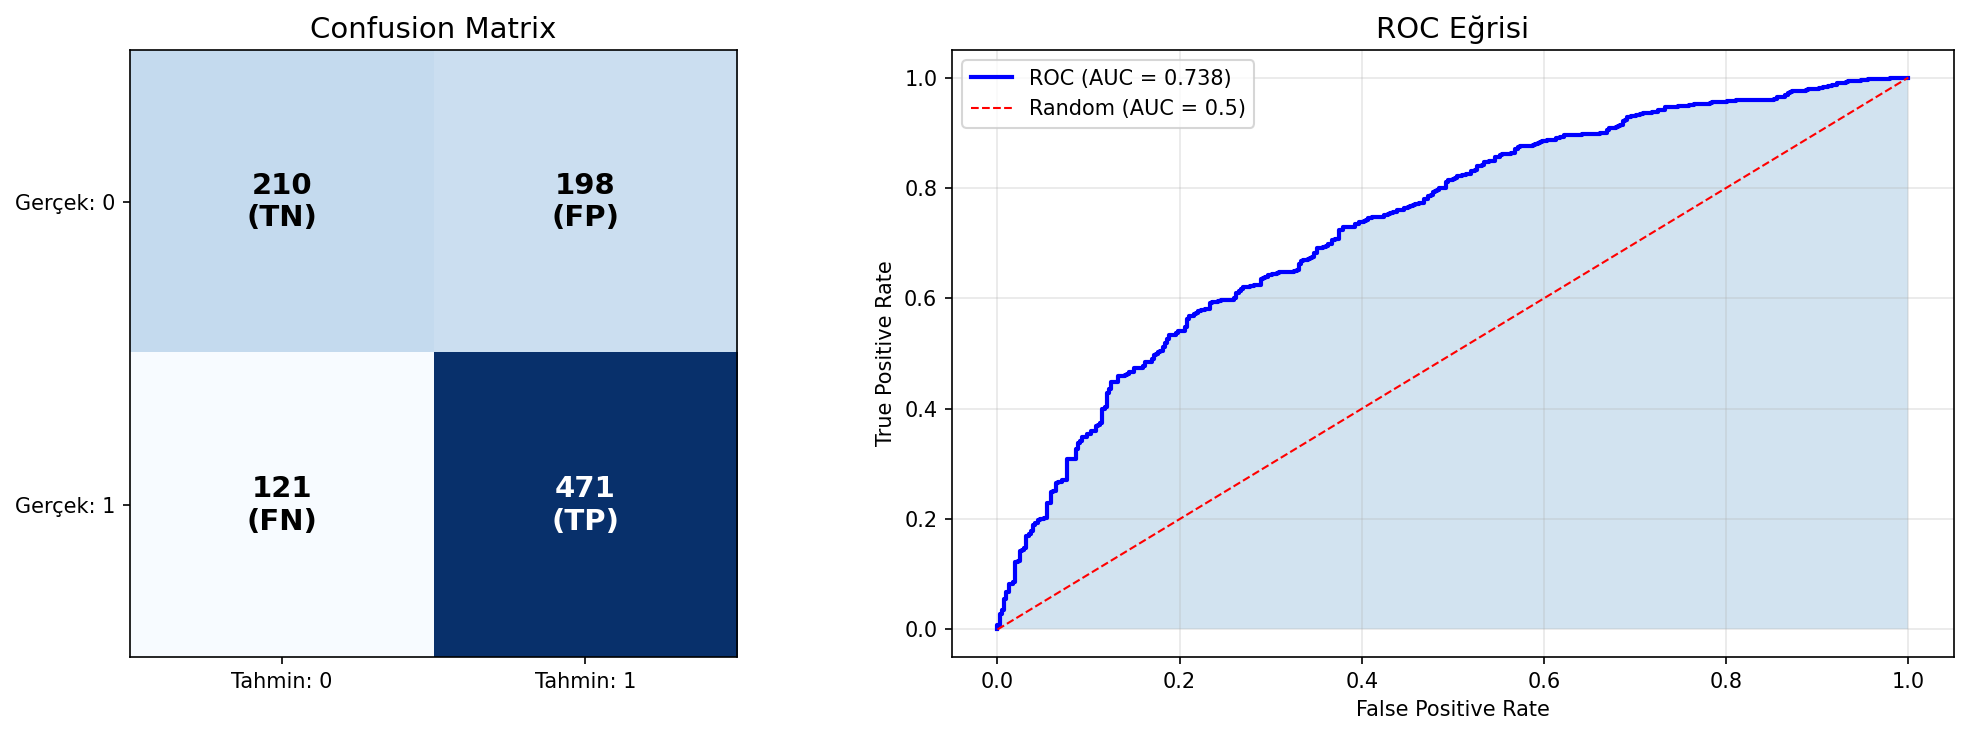

In [56]:
# Karmaşıklık Matrisi ve ROC Eğrisi Görselleştirme
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix heatmap
ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Tahmin: 0', 'Tahmin: 1'])
ax[0].set_yticklabels(['Gerçek: 0', 'Gerçek: 1'])
for i in range(2):
    for j in range(2):
        etiket = "TP" if i == 1 and j == 1 else "TN" if i == 0 and j == 0 else "FP" if i == 0 and j == 1 else "FN"
        ax[0].text(j, i, f'{cm[i, j]}\n({etiket})',
                   ha='center', va='center', fontsize=14, fontweight='bold',
                   color='white' if cm[i, j] > cm.max()/2 else 'black')
ax[0].set_title('Confusion Matrix', fontsize=14)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ax[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc_roc:.3f})')
ax[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
ax[1].fill_between(fpr, tpr, alpha=0.2)
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Eğrisi', fontsize=14)
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

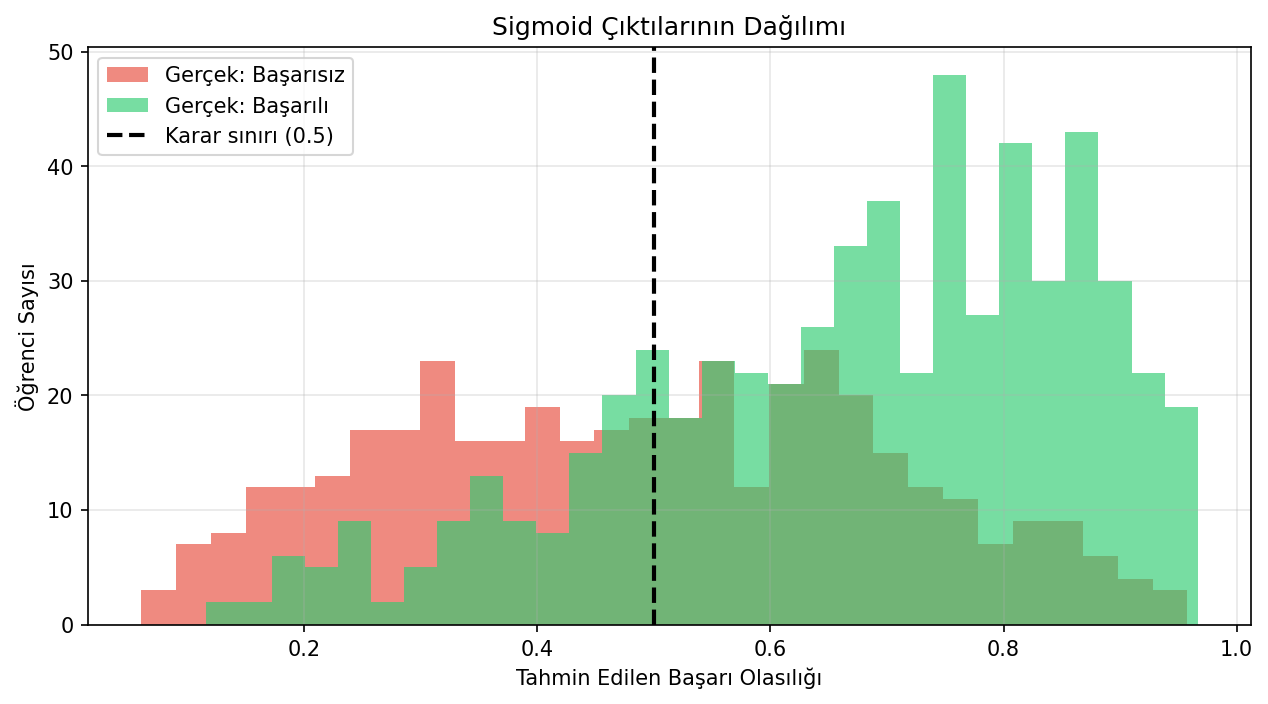

İki dağılım kısmen üst üste biniyor — model mükemmel ayıramıyor.
Bu beklenen bir sonuç: dönem sonu notunun %55'i (final + proje) henüz bilinmiyor.


In [57]:
# Tahmin edilen olasılıkların dağılımı
plt.figure(figsize=(10, 5))
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.65, label='Gerçek: Başarısız', color='#e74c3c')
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.65, label='Gerçek: Başarılı', color='#2ecc71')
plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Karar sınırı (0.5)')
plt.xlabel('Tahmin Edilen Başarı Olasılığı')
plt.ylabel('Öğrenci Sayısı')
plt.title('Sigmoid Çıktılarının Dağılımı')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("İki dağılım kısmen üst üste biniyor — model mükemmel ayıramıyor.")
print("Bu beklenen bir sonuç: dönem sonu notunun %55'i (final + proje) henüz bilinmiyor.")

## 9. Özellik Setlerinin Karşılaştırılması

Şimdi Bölüm 4'te tanımladığımız üç seti aynı koşullarda eğitip karşılaştırıyoruz. Bu bölüm, veri sızıntısının sonuçları nasıl çarpıttığını somut olarak gösteriyor.

In [58]:
setler = {
    'A: Tüm bileşen notları (SIZINTILI)': bilesenler,
    'B: Dönem içi + davranışsal (ANA MODEL)': sayisal_ozellikler,
    'C: Sadece davranışsal (REFERANS)': ['Attendance (%)', 'Study_Hours_per_Week',
                                          'Sleep_Hours_per_Night', 'Stress_Level (1-10)', 'Age'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
karsilastirma = []

for ad, ozellikler in setler.items():
    boru = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
    acc = cross_val_score(boru, df[ozellikler], y, cv=cv, scoring='accuracy')
    auc = cross_val_score(boru, df[ozellikler], y, cv=cv, scoring='roc_auc')
    karsilastirma.append({
        'Özellik Seti': ad,
        'Özellik Sayısı': len(ozellikler),
        'CV Doğruluk': f'{acc.mean():.4f}',
        'CV AUC': f'{auc.mean():.4f}'
    })

print("5-Katlı Çapraz Doğrulama Sonuçları:")
display(pd.DataFrame(karsilastirma))

5-Katlı Çapraz Doğrulama Sonuçları:


,Özellik Seti,Özellik Sayısı,CV Doğruluk,CV AUC
0,A: Tüm bileşen notları (SIZINTILI),6,0.9958,1.0000
1,B: Dönem içi + davranışsal (ANA MODEL),9,0.6938,0.7516
2,C: Sadece davranışsal (REFERANS),5,0.5922,0.4943


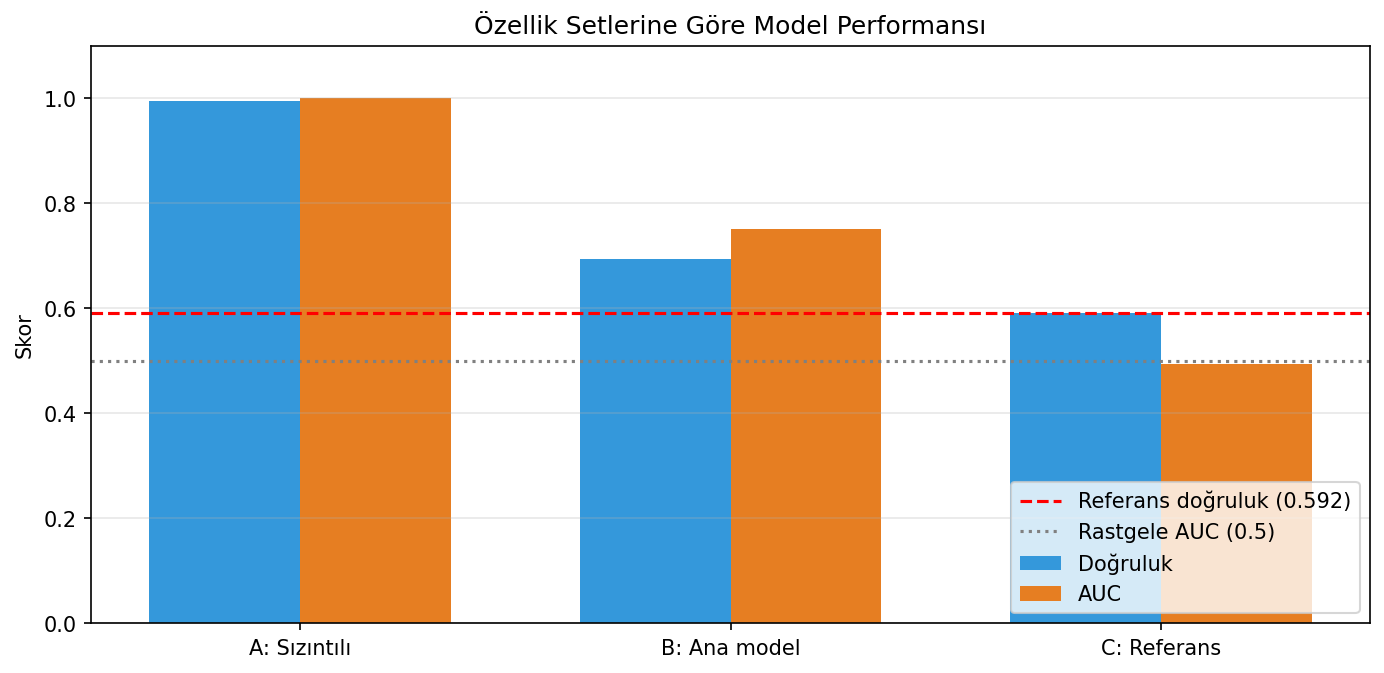

In [59]:
# Karşılaştırmanın görselleştirilmesi
sonuc_df = pd.DataFrame(karsilastirma)
x_pos = np.arange(len(sonuc_df))
genislik = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x_pos - genislik/2, sonuc_df['CV Doğruluk'].astype(float), genislik,
        label='Doğruluk', color='#3498db')
plt.bar(x_pos + genislik/2, sonuc_df['CV AUC'].astype(float), genislik,
        label='AUC', color='#e67e22')
plt.axhline(y=y.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Referans doğruluk ({y.mean():.3f})')
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, label='Rastgele AUC (0.5)')
plt.xticks(x_pos, ['A: Sızıntılı', 'B: Ana model', 'C: Referans'])
plt.ylabel('Skor')
plt.ylim(0, 1.1)
plt.title('Özellik Setlerine Göre Model Performansı')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 9.1 Karşılaştırmanın Yorumu

**Set A (%99+ doğruluk):** Kusursuz görünen bu sonuç aslında bir başarısızlıktır. Model hiçbir şey öğrenmemiş, sadece `Total_Score` formülünü tersine çevirmiştir. Gerçek hayatta bu özellikler elde olduğunda zaten harf notu da bellidir; tahmin edilecek bir şey kalmaz. **Ödevlerde en sık yapılan hata budur** — yüksek skor görünce durulur, skorun nereden geldiği sorgulanmaz.

**Set C (AUC ≈ 0.50):** Devamsızlık, çalışma saati, uyku ve stres değişkenleri hedefi hiç açıklamıyor. AUC'nin 0.50 olması "rastgele tahmin kadar iyi" demektir. Doğruluğun yine de %59 çıkması yanıltıcıdır: model her öğrenciye "başarılı" diyerek çoğunluk sınıfının oranını yakalar. **Bu, doğruluk metriğine tek başına neden güvenilmemesi gerektiğinin klasik örneğidir.**

**Set B (ana model):** Doğruluk referans çizgisinin üzerinde, AUC 0.50'nin belirgin biçimde üzerinde. Model gerçekten bilgi çıkarıyor ama mükemmel değil — çünkü dönem sonu notunun büyük kısmını belirleyen final ve proje notları henüz yok. **Gerçekçi ve savunulabilir olan sonuç budur.**

## 10. Örnek Tahmin

In [60]:
ornek = X_test.iloc[0:1]
ornek_scaled = scaler.transform(ornek)
ornek_olasilik = model.predict_proba(ornek_scaled)[0, 1]
ornek_tahmin = model.predict(ornek_scaled)[0]

print("Örnek öğrenci verisi:")
display(ornek)
print(f"\nBaşarı olasılığı: {ornek_olasilik:.4f} ({ornek_olasilik*100:.1f}%)")
print(f"Tahmin: {ornek_tahmin} ({'Başarılı' if ornek_tahmin == 1 else 'Başarısız'})")
print(f"Gerçek: {y_test.iloc[0]} ({'Başarılı' if y_test.iloc[0] == 1 else 'Başarısız'})")

Örnek öğrenci verisi:


,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Attendance (%),Study_Hours_per_Week,Sleep_Hours_per_Night,Stress_Level (1-10),Age,Gender_Male,Department_CS,Department_Engineering,Department_Mathematics,Extracurricular_Activities_Yes,Internet_Access_at_Home_Yes,Family_Income_Level_Low,Family_Income_Level_Medium
1613,42.02,85.43,77.22,29.3,63.42,21.6,8.4,10,18,1,1,0,0,0,1,0,1



Başarı olasılığı: 0.4639 (46.4%)
Tahmin: 0 (Başarısız)
Gerçek: 0 (Başarısız)


In [61]:
# Risk altındaki öğrencileri listeleme (pratik kullanım senaryosu)
test_sonuclari = pd.DataFrame({
    'Basari_Olasiligi': y_pred_proba,
    'Tahmin': y_pred,
    'Gercek': y_test.values
}, index=y_test.index)

riskli = test_sonuclari.sort_values('Basari_Olasiligi').head(10)
riskli = riskli.join(df[['Student_ID', 'Midterm_Score', 'Attendance (%)']])

print("EN RİSKLİ 10 ÖĞRENCİ (erken uyarı listesi):")
display(riskli[['Student_ID', 'Midterm_Score', 'Attendance (%)',
                'Basari_Olasiligi', 'Gercek']].round(3))
print("\nPratik kullanım: bu öğrenciler dönem ortasında ek destek programına alınabilir.")

EN RİSKLİ 10 ÖĞRENCİ (erken uyarı listesi):


,Student_ID,Midterm_Score,Attendance (%),Basari_Olasiligi,Gercek
2861,S3861,41.05,92.43,0.060,0
1837,S2837,42.73,60.97,0.085,0
1147,S2147,44.94,70.78,0.086,0
4616,S5616,43.30,80.65,0.093,0
929,S1929,54.56,84.87,0.098,0
4234,S5234,43.72,53.83,0.101,0
2223,S3223,50.99,83.96,0.105,0
4655,S5655,45.17,82.44,0.113,0
4398,S5398,50.77,88.16,0.115,1
2049,S3049,46.93,94.89,0.115,0



Pratik kullanım: bu öğrenciler dönem ortasında ek destek programına alınabilir.


## 11. Bulgular

**1. `Total_Score` deterministik bir formül.** Altı bileşen notunun ağırlıklı ortalaması: 0.30 proje + 0.25 final + 0.15 vize + 0.15 ödev + 0.10 quiz + 0.05 katılım. Bileşen notlarıyla kurulan lineer regresyonun R² değeri tam olarak 1.000000.

**2. Üç özellik setinin karşılaştırması:**

| Set | Doğruluk | AUC |
|---|---|---|
| A: Tüm bileşen notları | 0.996 | 1.000 |
| B: Dönem içi + davranışsal | 0.694 | 0.752 |
| C: Sadece davranışsal | 0.592 | 0.494 |

Set A'nın %99.6'sı dairesel — model tahmin etmiyor, formülü geri çözüyor. Set C'nin %59 doğruluk alması ama AUC'sinin 0.49 olması, doğruluk metriğine tek başına neden güvenilmemesi gerektiğini gösteriyor: model her öğrenciye "başarılı" diyerek çoğunluk sınıfının oranını yakalıyor.

**3. Ana model (Set B):** Test doğruluk 0.681, AUC 0.738. Referans (çoğunluk sınıfı) 0.592. Model gerçekten bilgi çıkarıyor ama mükemmel değil — dönem sonu notunun %55'ini belirleyen final ve proje notları henüz yok.

**4. En yüksek katsayı büyüklüğüne sahip özellik: Midterm_Score.** Cinsiyet, bölüm, internet erişimi, aile geliri ve ders dışı etkinlik katsayıları sıfıra çok yakın — veri seti sentetik üretildiği için demografik değişkenlerle başarı arasına kasıtlı bir ilişki konulmamış.

**5. Kullanılmayan dosya:** Arşivdeki `Students_Grading_Dataset_Biased.csv` dosyasında `Total_Score` ile hiçbir değişken arasında korelasyon yok (tüm |r| < 0.04). Analizde kullanılmadı.

**Metodolojik çıkarım:** Model kurmadan önce hedef değişkenin nasıl üretildiğini incelemek, metrikleri iyileştirmeye çalışmaktan daha önemli.